## **Setup and Imports**

In [3]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
sns.set_palette("husl")  # Remove the plt.style.use line

# Add path to access modules
code_path = '/kaggle/input/datasets/imadsaeed123/vehicle-sale-data/Vehicle Sales Data/code'
sys.path.insert(0, code_path)
sys.path.insert(0, os.path.join(code_path, 'Script'))
sys.path.insert(0, os.path.join(code_path, 'modules'))

# Import the Gradient Boosting class
from Regression_Gradient_Boosting_Algo import GradientBoostingModels

print(" \N{CHECK MARK} Setup complete!")

 ✓ Setup complete!


## **Initialize Trainer (Loads Data)**

In [4]:
# Path to your CSV file
file_path = '/kaggle/input/datasets/imadsaeed123/vehicle-sale-data/Vehicle Sales Data/archive/car_prices.csv'

# Create trainer instance (automatically loads and preprocesses data)
trainer = GradientBoostingModels(file_path)

print("\N{CHECK MARK} \nTrainer initialized! Data is ready for gradient boosting.")

GRADIENT BOOSTING REGRESSION MODELS

Ὄ2 Loading preprocessed data...
✅ Loaded 558,837 rows and 16 columns

STEP 1: CLEANING DATA
✅ Dropped columns: ['vin']
✅ Cleaned transmission column - fixed invalid values
⚠️ Dropped saledate (could not parse)

STEP 2: HANDLING MISSING VALUES
Missing values found: {'make': np.int64(10301), 'model': np.int64(10399), 'trim': np.int64(10651), 'body': np.int64(13195), 'condition': np.int64(11820), 'odometer': np.int64(94), 'color': np.int64(749), 'interior': np.int64(749), 'mmr': np.int64(38), 'sellingprice': np.int64(12)}
✅ Filled transmission missing values with 'automatic'
✅ Filled make missing values with mode: 'Ford'
✅ Filled model missing values with mode: 'Altima'
✅ Filled trim missing values with mode: 'Base'
✅ Filled body missing values with mode: 'Sedan'
✅ Filled color missing values with mode: 'black'
✅ Filled interior missing values with mode: 'black'
✅ Filled condition missing values with median: 35.00
✅ Filled odometer missing values with 

## **Train HistGradientBoosting (Built -in sklearn)**

In [5]:
# Train HistGradientBoosting Regressor
model_hgb, metrics_hgb = trainer.train_hist_gradient_boosting(max_iter=200)
print("\n \N{CHECK MARK} HistGradientBoosting training complete!")


Ὄ8 Training HistGradientBoosting (iterations=200)
Binning 0.090 GB of training data: 0.415 s
Binning 0.010 GB of validation data: 0.021 s
Fitting gradient boosted rounds:
Fit 200 trees in 9.559 s, (6200 total leaves)
Time spent computing histograms: 6.679s
Time spent finding best splits:  0.230s
Time spent applying splits:      0.889s
Time spent predicting:           0.210s

ὌA Results:
   Training R²: 0.9564
   Test R²: 0.9544
   Test MAE: $0.12
   Test RMSE: $0.22
   Test MAPE: 12.11%
   Training time: 9.56 seconds
   ὋE Model saved: hist_gradient_boosting.pkl
   ὍD Predictions saved: histgradientboosting_predictions.csv

 ✓ HistGradientBoosting training complete!


## **Train XGBoost**

In [8]:
# Train XGBoost Regressor
model_xgb, metrics_xgb = trainer.train_xgboost(n_estimators=200, learning_rate=0.05)
print("\n \N{CHECK MARK} XGBoost training complete!")


Ὄ8 Training XGBoost (n_estimators=200, lr=0.05)

ὌA Results:
   Training R²: 0.9546
   Test R²: 0.9528
   Test MAE: $0.12
   Test RMSE: $0.22
   Test MAPE: 12.32%
   Training time: 4.92 seconds
   ὋE Model saved: xgboost_regressor.pkl
   ὍD Predictions saved: xgboost_predictions.csv

ὑD Top 10 Features (XGBoost):
      mmr: 0.9459
      condition: 0.0161
      seller_encoded: 0.0083
      odometer: 0.0059
      state_encoded: 0.0034
      model_encoded: 0.0031
      year: 0.0029
      interior_—: 0.0019
      make_encoded: 0.0015
      transmission_manual: 0.0013

 ✓ XGBoost training complete!


## **Train LightGBM**

In [7]:
# Train LightGBM Regressor
model_lgb, metrics_lgb = trainer.train_lightgbm(n_estimators=200, learning_rate=0.05)
print("\n \N{CHECK MARK}.LightGBM training complete!")


Ὄ8 Training LightGBM (n_estimators=200, lr=0.05)
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.034312 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 1590
[LightGBM] [Info] Number of data points in the train set: 447069, number of used features: 27
[LightGBM] [Info] Start training from score 9.206892

ὌA Results:
   Training R²: 0.9533
   Test R²: 0.9529
   Test MAE: $0.12
   Test RMSE: $0.22
   Test MAPE: 12.31%
   Training time: 4.12 seconds
   ὋE Model saved: lightgbm_regressor.pkl
   ὍD Predictions saved: lightgbm_predictions.csv

ὑD Top 10 Features (LightGBM):
      condition: 1209.0000
      mmr: 1146.0000
      odometer: 720.0000
      state_encoded: 681.0000
      seller_encoded: 635.0000
      year: 438.0000
      model_encoded: 390.0000
      make_encoded: 322.0000
      trim_encoded: 173.0000
      body_encoded: 129.0000

 LightGBM training complete!


## **Train CatBoost**

In [9]:
# Train CatBoost Regressor
model_cb, metrics_cb = trainer.train_catboost(iterations=200, learning_rate=0.05)
print("\n \N{CHECK MARK} CatBoost training complete!")


Ὄ8 Training CatBoost (iterations=200, lr=0.05)
0:	learn: 0.8803315	total: 102ms	remaining: 20.4s
1:	learn: 0.8419238	total: 143ms	remaining: 14.2s
2:	learn: 0.8053599	total: 179ms	remaining: 11.8s
3:	learn: 0.7708026	total: 215ms	remaining: 10.5s
4:	learn: 0.7380079	total: 250ms	remaining: 9.76s
5:	learn: 0.7069231	total: 287ms	remaining: 9.28s
6:	learn: 0.6774552	total: 325ms	remaining: 8.96s
7:	learn: 0.6498373	total: 360ms	remaining: 8.63s
8:	learn: 0.6237468	total: 394ms	remaining: 8.36s
9:	learn: 0.5986019	total: 428ms	remaining: 8.13s
10:	learn: 0.5750310	total: 462ms	remaining: 7.94s
11:	learn: 0.5527251	total: 497ms	remaining: 7.78s
12:	learn: 0.5318177	total: 534ms	remaining: 7.68s
13:	learn: 0.5121724	total: 568ms	remaining: 7.55s
14:	learn: 0.4932972	total: 604ms	remaining: 7.44s
15:	learn: 0.4755068	total: 638ms	remaining: 7.33s
16:	learn: 0.4589326	total: 673ms	remaining: 7.25s
17:	learn: 0.4432562	total: 709ms	remaining: 7.17s
18:	learn: 0.4284667	total: 744ms	remaining:

## **Compare All Models**

In [10]:
#  Compare all gradient boosting models
results_df = trainer.save_all_results()

print("\n" + "="*60)
print(" GRADIENT BOOSTING MODEL COMPARISON")
print("="*60)
print(results_df.to_string(index=False))

# Get best model
best_model_name = results_df.iloc[0]['Model']
best_r2 = results_df.iloc[0]['Test R²']
best_mape = results_df.iloc[0]['Test MAPE (%)']

print(f"\n BEST GRADIENT BOOSTING MODEL: {best_model_name}")
print(f"   Test R²: {best_r2:.4f}")
print(f"   Test MAPE: {best_mape:.2f}%")


ὌA GRADIENT BOOSTING MODEL COMPARISON
                          Model  Train R²  Test R²  Test MAE ($)  Test RMSE ($)  Test MAPE (%)  Training Time (s)
HistGradientBoosting (iter=200)  0.956353 0.954412      0.117981       0.216252      12.111491           9.560931
               LightGBM (n=200)  0.953253 0.952929      0.119531       0.220101      12.312945           4.118217
                XGBoost (n=200)  0.954573 0.952837      0.119524       0.220338      12.319405           4.862999
                XGBoost (n=200)  0.954573 0.952837      0.119524       0.220338      12.319405           4.918867
            CatBoost (iter=200)  0.949899 0.950498      0.123487       0.226304      12.732603           7.103217

✅ Results saved to:
   CSV: /kaggle/working/results/gradient_boosting_comparison.csv
   JSON: /kaggle/working/results/gradient_boosting_comparison.json

Ἴ5 BEST GRADIENT BOOSTING MODEL: HistGradientBoosting (iter=200)
   Test R²: 0.9544
   Test MAPE: 12.11%

 GRADIENT BOOSTIN

## **Plot Actual vs Predicted (Best Model)**

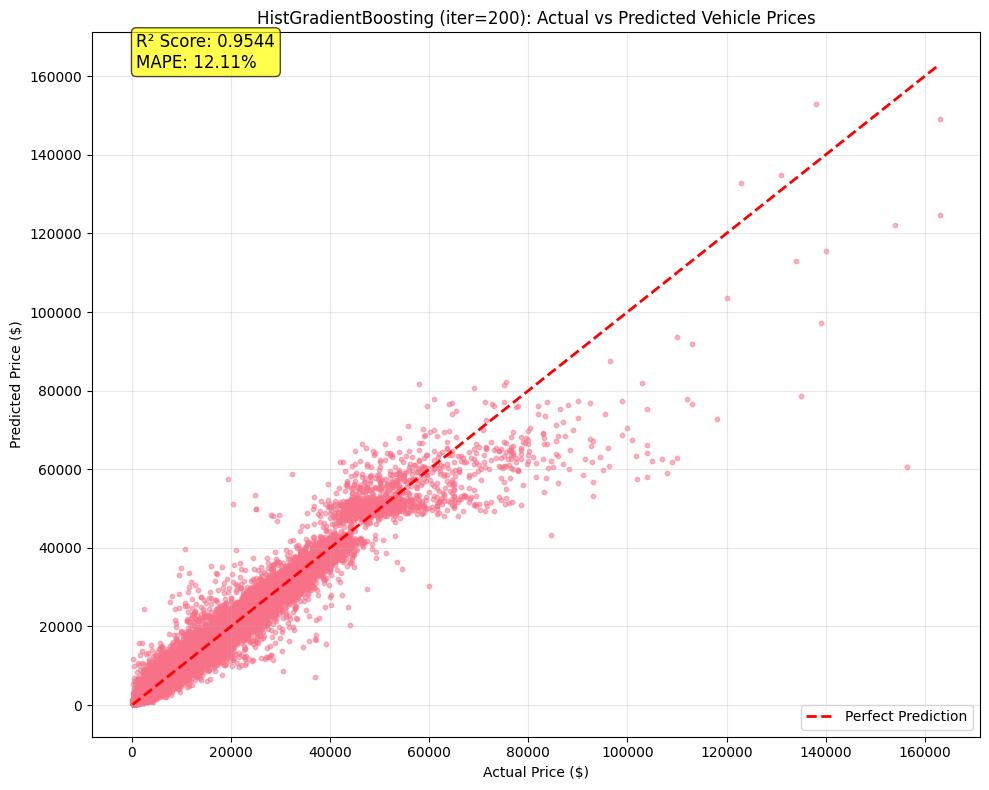

 Plot saved to: /kaggle/working/results/gb_actual_vs_predicted.png


In [11]:
# Plot Actual vs Predicted for the best model
def inverse_transform_price(log_value):
    return np.expm1(log_value)

# Map model names to model objects
models_map = {
    'HistGradientBoosting (iter=200)': model_hgb,
    'XGBoost (n=200)': model_xgb,
    'LightGBM (n=200)': model_lgb,
    'CatBoost (iter=200)': model_cb
}

# Get best model
best_model_name = results_df.iloc[0]['Model']
best_model = models_map[best_model_name]

# Get predictions
y_pred_best = best_model.predict(trainer.X_test)

# Transform to actual prices
y_test_actual = inverse_transform_price(trainer.y_test)
y_pred_actual = inverse_transform_price(y_pred_best)

# Plot
plt.figure(figsize=(10, 8))
plt.scatter(y_test_actual, y_pred_actual, alpha=0.5, s=10)
plt.plot([y_test_actual.min(), y_test_actual.max()], 
         [y_test_actual.min(), y_test_actual.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('Actual Price ($)')
plt.ylabel('Predicted Price ($)')
plt.title(f'{best_model_name}: Actual vs Predicted Vehicle Prices')
plt.legend()
plt.grid(True, alpha=0.3)

# Add R² score and MAPE
best_r2 = results_df.iloc[0]['Test R²']
best_mape = results_df.iloc[0]['Test MAPE (%)']
plt.text(0.05, 0.95, f'R² Score: {best_r2:.4f}\nMAPE: {best_mape:.2f}%', 
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(boxstyle="round,pad=0.3", facecolor="yellow", alpha=0.7))

plt.tight_layout()
plt.savefig('/kaggle/working/results/gb_actual_vs_predicted.png', dpi=150)
plt.show()
print(" Plot saved to: /kaggle/working/results/gb_actual_vs_predicted.png")

## **Residual Analysis**

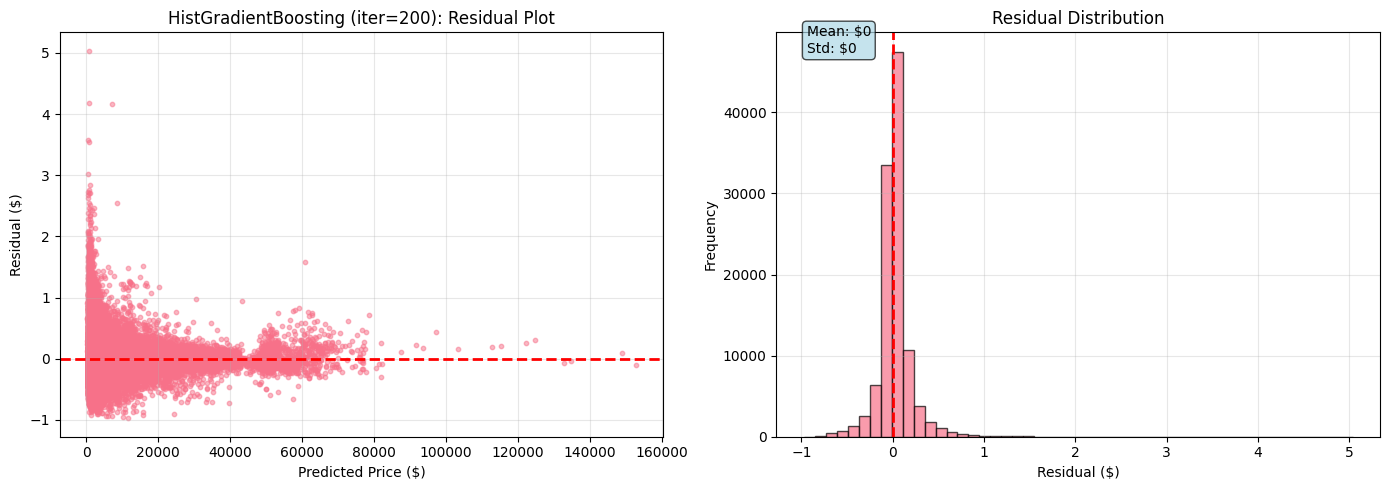

 Plot saved to: /kaggle/working/results/gb_residual_analysis.png


In [12]:
# Residual plot for the best model
residuals = trainer.y_test - y_pred_best
residuals_actual = inverse_transform_price(residuals)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Residuals vs Predicted
axes[0].scatter(y_pred_actual, residuals_actual, alpha=0.5, s=10)
axes[0].axhline(y=0, color='r', linestyle='--', lw=2)
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residual ($)')
axes[0].set_title(f'{best_model_name}: Residual Plot')
axes[0].grid(True, alpha=0.3)

# Residual distribution
axes[1].hist(residuals_actual, bins=50, edgecolor='black', alpha=0.7)
axes[1].axvline(x=0, color='r', linestyle='--', lw=2)
axes[1].set_xlabel('Residual ($)')
axes[1].set_ylabel('Frequency')
axes[1].set_title('Residual Distribution')
axes[1].grid(True, alpha=0.3)

# Add statistics
mean_residual = residuals_actual.mean()
std_residual = residuals_actual.std()
axes[1].text(0.05, 0.95, f'Mean: ${mean_residual:,.0f}\nStd: ${std_residual:,.0f}', 
             transform=axes[1].transAxes, fontsize=10,
             bbox=dict(boxstyle="round,pad=0.3", facecolor="lightblue", alpha=0.7))

plt.tight_layout()
plt.savefig('/kaggle/working/results/gb_residual_analysis.png', dpi=150)
plt.show()
print(" Plot saved to: /kaggle/working/results/gb_residual_analysis.png")

## **Model Comparison Bar Chart**

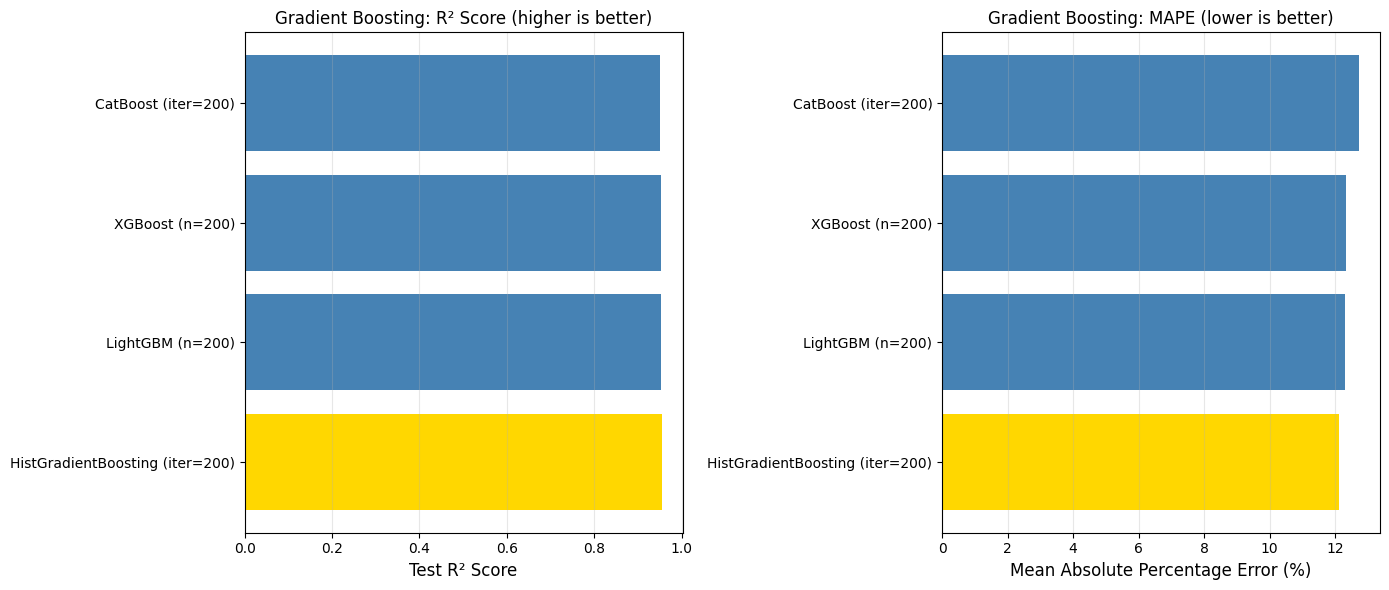

 Model comparison chart saved!


In [13]:
# Visual comparison of all gradient boosting models
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plot 1: R² Scores
colors = ['gold' if i == 0 else 'steelblue' for i in range(len(results_df))]
axes[0].barh(results_df['Model'], results_df['Test R²'], color=colors)
axes[0].set_xlabel('Test R² Score', fontsize=12)
axes[0].set_title('Gradient Boosting: R² Score (higher is better)', fontsize=12)
axes[0].grid(True, alpha=0.3, axis='x')

# Plot 2: MAPE (lower is better)
axes[1].barh(results_df['Model'], results_df['Test MAPE (%)'], color=colors)
axes[1].set_xlabel('Mean Absolute Percentage Error (%)', fontsize=12)
axes[1].set_title('Gradient Boosting: MAPE (lower is better)', fontsize=12)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig('/kaggle/working/results/gb_model_comparison.png', dpi=150)
plt.show()
print(" Model comparison chart saved!")